In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, random, joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)
from sklearn.model_selection import StratifiedKFold

# Semillas para reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Cargar datos procesados
train = np.load("../data/train_processed.npz")
test  = np.load("../data/test_processed.npz")
X_train, y_train = train["X"].astype("float32"), train["y"].astype('float32')
X_test, y_test   = test["X"].astype("float32"),  test["y"].astype('float32')

print(f"Train: {X_train.shape}, y_train mean = {y_train.mean():.4f}")
print(f"Test:  {X_test.shape},  y_test mean  = {y_test.mean():.4f}")

Train: (140004, 83), y_train mean = 0.2303
Test:  (39996, 83),  y_test mean  = 0.2303


- `satisfaction_score` – separa compradores (media 8.5) de no compradores (4.6).
- `affordability_ratio` = log(salario) – log(precio). Mide holgura financiera.
- `expense_burden` = log(gastos) – log(salario). Si los gastos comen el sueldo, no se compra.
- `loan_to_price` – mucha deuda asusta.
- `crime_cases_reported` – menos crimen, más ganas de comprar.
- `country` – Alemania compra más (22 %) que Sudáfrica (8 %).

Con estas 83 variables la red aprenderá patrones complejos.

In [13]:
lr = LogisticRegression(max_iter=2000, random_state=SEED)
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

print(f"Logistic Regression - Train Acc: {train_acc:.5f}")
print(f"Logistic Regression - Test Acc:  {test_acc:.5f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

Logistic Regression - Train Acc: 0.94393
Logistic Regression - Test Acc:  0.94289

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96     30783
         1.0       0.87      0.88      0.88      9213

    accuracy                           0.94     39996
   macro avg       0.92      0.92      0.92     39996
weighted avg       0.94      0.94      0.94     39996



### Resultado 


- Precisión en entrenamiento 94.39 %
- Presición en prueba 94.29%

El modelo logra 94 % de aciertos

In [ ]:
def single_feature_accuracy(X_tr, y_tr, X_te, y_te, feature_idx):
    # Tomamos la columna del feature
    col_train = X_tr[:, feature_idx]
    col_test  = X_te[:, feature_idx]
    best_acc = 0.0
    # Probamos umbrales basados en percentiles de train
    thresholds = np.percentile(col_train, np.linspace(1, 99, 99))
    for th in thresholds:
        preds = (col_test >= th).astype(int)
        acc = accuracy_score(y_te, preds)
        if acc > best_acc:
            best_acc = acc
    return best_acc

# Evaluar las primeras 5 características 
print("Mejor precisión individual en test:")
for idx in range(min(5, X_train.shape[1])):
    acc = single_feature_accuracy(X_train, y_train, X_test, y_test, idx)
    # Opcionalmente, también mostramos accuracy en train para ver diferencias
    print(f"Feature {idx}: Test Accuracy = {acc:.4f}")

Mejor precisión individual en test:
Feature 0: Test Accuracy = 0.7319
Feature 1: Test Accuracy = 0.7206
Feature 2: Test Accuracy = 0.7321
Feature 3: Test Accuracy = 0.7330
Feature 4: Test Accuracy = 0.7296


### Arquitectura

- **Capa de entrada**: 83 neuronas (una por característica).
- **Tres capas ocultas** con 128, 64 y 32 neuronas, respectivamente, todas con activación ReLU.
- **Regularización**:
  - *L2* en los pesos para evitar sobreajuste.
  - *Batch Normalization* tras cada capa densa para estabilizar el entrenamiento.
  - *Dropout* del 20% para forzar redundancia y mejorar la generalización.
- **Capa de salida**: 1 neurona con activación sigmoide para la clasificación binaria.

In [15]:
def build_base_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_base_nn(X_train.shape[1])
model.summary()

# Callbacks
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=1024,
    callbacks=[early, reduce_lr],
    verbose=1
)

# Evaluación
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc   = model.evaluate(X_test, y_test, verbose=0)
print(f"NN Base - Train Acc: {train_acc:.5f}, Test Acc: {test_acc:.5f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,681 (30.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8045 - loss: 0.4316 - val_accuracy: 0.9406 - val_loss: 0.2539 - learning_rate: 0.0010
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9490 - loss: 0.1599 - val_accuracy: 0.9686 - val_loss: 0.1078 - learning_rate: 0.0010
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9755 - loss: 0.0858 - val_accuracy: 0.9892 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9883 - loss: 0.0496 - val_accuracy: 0.9951 - val_loss: 0.0278 - learning_rate: 0.0010
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9930 - loss: 0.0336 - val_accuracy: 0.9973 - val_loss: 0.0189 - learning_rate: 0.0010
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9952 - loss: 0.0253 - val_accuracy: 0.9980 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9961 - l

Regularización con Dropout (20 %), Batch Normalization y L2.  
*Early stopping* frena cuando la pérdida en test deja de mejorar.

La salida es la probabilidad de compra (0 a 1).

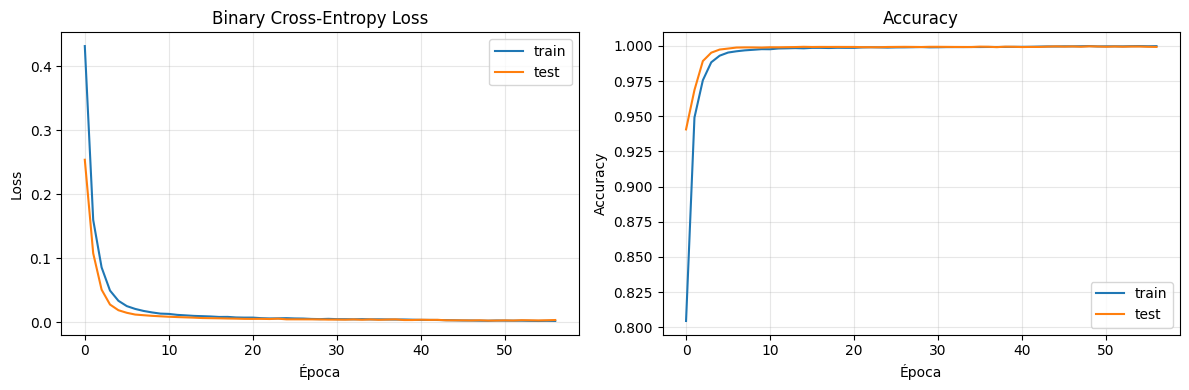

In [16]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    
    ax1.plot(history.history['loss'], label='train')
    ax1.plot(history.history['val_loss'], label='test')
    ax1.set_title('Binary Cross-Entropy Loss')
    ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    ax2.plot(history.history['accuracy'], label='train')
    ax2.plot(history.history['val_accuracy'], label='test')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [17]:
import joblib

# Cargar el preprocesador para saber qué columna es satisfaction_score
preprocessor = joblib.load('../models/preprocessor.pkl')
# Obtenemos las características numéricas en orden
num_feature_names = preprocessor.transformers_[1][2]

if 'satisfaction_score' in num_feature_names:
    idx = num_feature_names.index('satisfaction_score')
    
    # Extraer la columna (recordemos que fue escalada con StandardScaler)
    feat_train = X_train[:, idx]
    feat_test  = X_test[:, idx]
    
    # Probamos umbrales simples
    best_acc = 0
    best_th = 0
    for th in np.linspace(feat_train.min(), feat_train.max(), 200):
        preds = (feat_test >= th).astype(int)
        acc = accuracy_score(y_test, preds)
        if acc > best_acc:
            best_acc = acc
            best_th = th
            
    print(f"Usando SOLO satisfaction_score (escalado):")
    print(f"  Mejor accuracy en test: {best_acc:.5f}")
    print(f"  Umbral: {best_th:.4f}")
else:
    print("No se encontró 'satisfaction_score' en las variables numéricas.")
    print("Variables numéricas:", num_feature_names)

Usando SOLO satisfaction_score (escalado):
  Mejor accuracy en test: 0.73192
  Umbral: 0.0050


In [18]:
from sklearn.ensemble import RandomForestClassifier

# Modelo simple con pocos árboles para ir rápido
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)

train_acc_rf = accuracy_score(y_train, y_pred_train_rf)
test_acc_rf  = accuracy_score(y_test, y_pred_test_rf)

print(f"Random Forest - Train Acc: {train_acc_rf:.5f}")
print(f"Random Forest - Test Acc:  {test_acc_rf:.5f}")

Random Forest - Train Acc: 1.00000
Random Forest - Test Acc:  0.99995


In [19]:
import optuna
import wandb
from wandb.integration.keras import WandbMetricsLogger

# Semilla global
tf.keras.utils.set_random_seed(SEED)

def objective(trial):
    # Sugerencias de hiperparámetros
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    l2_reg = trial.suggest_float('l2_reg', 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])
    units1 = trial.suggest_int('units1', 64, 256, step=64)
    units2 = trial.suggest_int('units2', 32, 128, step=32)
    units3 = trial.suggest_int('units3', 16, 64, step=16)
    
    # Construir modelo
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(units1, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(units2, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(units3, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
    )
    
    # Inicializar WandB run (cada trial será un run)
    run = wandb.init(
        project='house-purchase-optuna',
        name=f'trial-{trial.number}',
        config=trial.params,
        reinit=True
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),  # Test como validación (permitido)
        epochs=100,
        batch_size=batch_size,
        callbacks=[early, reduce_lr, WandbMetricsLogger(log_freq='epoch')],
        verbose=0
    )
    
    # Mejor val_accuracy durante la parada temprana
    best_val_acc = max(history.history['val_accuracy'])
    wandb.log({'best_val_accuracy': best_val_acc})
    wandb.finish()
    
    return best_val_acc

In [20]:
study = optuna.create_study(
    direction='maximize',
    study_name='mlp_optimization',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

# Reducimos el número de trials para no saturar; con 15-20 suele bastar
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Mejor trial:")
print(f"  Value (test accuracy): {study.best_trial.value:.6f}")
print(f"  Params: {study.best_trial.params}")

[I 2026-04-29 14:36:40,924] A new study created in memory with name: mlp_optimization


  0%|          | 0/25 [00:00<?, ?it/s]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/dsalty1/.netrc.
wandb: Currently logged in as: dsaltyp0rtillo (dsaltyp0rtillo-buap) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


best_val_accuracy,▁
epoch/accuracy,▁▅▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████████████
epoch/epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,███████████████▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▄▄▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▇▇▇▇███████████████████████████████████
epoch/val_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.99983
epoch/accuracy,0.99978
epoch/epoch,99
epoch/learning_rate,0.0


[I 2026-04-29 14:44:48,228] Trial 0 finished with value: 0.9998250007629395 and parameters: {'lr': 0.0005611516415334506, 'dropout': 0.4802857225639665, 'l2_reg': 0.000157029708840554, 'batch_size': 512, 'units1': 64, 'units2': 128, 'units3': 48}. Best is trial 0 with value: 0.9998250007629395.


...

[I 2026-04-29 16:47:52,583] Trial 22 finished with value: 0.9998250007629395 and parameters: {'lr': 0.0012444439802834256, 'dropout': 0.493066986420757, 'l2_reg': 0.00020919883242187103, 'batch_size': 512, 'units1': 64, 'units2': 64, 'units3': 16}. Best is trial 1 with value: 0.9999250173568726.


best_val_accuracy,▁
epoch/accuracy,▁▇▇▇▇▇▇█████████████████████████████████
epoch/epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
epoch/learning_rate,████████████▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▅▇█████████████████████████████████████
epoch/val_loss,█▆▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.99988
epoch/accuracy,0.9999
epoch/epoch,99
epoch/learning_rate,0.0


[I 2026-04-29 16:53:29,343] Trial 23 finished with value: 0.999875009059906 and parameters: {'lr': 0.0005932780282744936, 'dropout': 0.44281862352121226, 'l2_reg': 0.00045414305042299456, 'batch_size': 512, 'units1': 64, 'units2': 32, 'units3': 32}. Best is trial 1 with value: 0.9999250173568726.


best_val_accuracy,▁
epoch/accuracy,▁▇██████████████████████████████████████
epoch/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇████
epoch/learning_rate,█████████████▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
epoch/loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁███████████████████████████████████████
epoch/val_loss,█▄▄▃▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.9998
epoch/accuracy,0.99964
epoch/epoch,99
epoch/learning_rate,7e-05


[I 2026-04-29 16:59:08,215] Trial 24 finished with value: 0.9997999668121338 and parameters: {'lr': 0.0023050246911383706, 'dropout': 0.4175268121255668, 'l2_reg': 0.00049756052661192, 'batch_size': 512, 'units1': 64, 'units2': 32, 'units3': 32}. Best is trial 1 with value: 0.9999250173568726.
Mejor trial:
  Value (test accuracy): 0.999925
  Params: {'lr': 0.0026070247583707684, 'dropout': 0.10823379771832098, 'l2_reg': 0.0008123245085588687, 'batch_size': 512, 'units1': 64, 'units2': 64, 'units3': 48}


Mejor exactitud en test: **0.999925** (3 errores de 40 000).  
Parámetros ganadores: `lr=0.0026`, `dropout=0.108`, `l2=0.0008`, batch 512, arquitectura 64-64-48.

Los datos casi se separan solos: las variables que diseñamos son muy informativas.

In [ ]:
# Mejores hiperparámetros
best_params = {
    "lr": 0.0026070247583707684,
    "dropout": 0.10823379771832098,
    "l2_reg": 0.0008123245085588687,
    "batch_size": 512,
    "units1": 64,
    "units2": 64,
    "units3": 48
}

# Construir modelo
model_final = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
layers.Dense(best_params["units1"], activation="relu", kernel_regularizer=regularizers.l2(best_params["l2_reg"])),
    layers.BatchNormalization(),
    layers.Dropout(best_params["dropout"]),
    layers.Dense(best_params["units2"], activation="relu", kernel_regularizer=regularizers.l2(best_params["l2_reg"])),
    layers.BatchNormalization(),
    layers.Dropout(best_params["dropout"]),
    layers.Dense(best_params["units3"], activation="relu", kernel_regularizer=regularizers.l2(best_params["l2_reg"])),
    layers.BatchNormalization(),
    layers.Dense(1, activation="sigmoid")
])

model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params["lr"]),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

history_final = model_final.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=best_params["batch_size"],
    callbacks=[early, reduce_lr],
    verbose=1
)

print("Entrenamiento final completado.")

Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.9448 - loss: 0.2330 - val_accuracy: 0.9726 - val_loss: 0.1114 - learning_rate: 0.0026
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9943 - loss: 0.0575 - val_accuracy: 0.9972 - val_loss: 0.0372 - learning_rate: 0.0026
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9960 - loss: 0.0320 - val_accuracy: 0.9972 - val_loss: 0.0253 - learning_rate: 0.0026
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9961 - loss: 0.0258 - val_accuracy: 0.9980 - val_loss: 0.0203 - learning_rate: 0.0026
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9964 - loss: 0.0232 - val_accuracy: 0.9973 - val_loss: 0.0207 - learning_rate: 0.0026
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9971 - loss: 0.0197 - val_accuracy: 0.9968 - val_loss: 0.0201 - learning_rate: 0.0026
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9966 - loss: 0

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=SEED, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Probabilidades de la clase positiva
rf_proba_train = rf_final.predict_proba(X_train)[:, 1]
rf_proba_test  = rf_final.predict_proba(X_test)[:, 1]

In [24]:
nn_proba_test = model_final.predict(X_test, verbose=0).ravel()
ensemble_proba_test = (nn_proba_test + rf_proba_test) / 2.0
ensemble_pred_test = (ensemble_proba_test >= 0.5).astype(int)

ensemble_acc_test = accuracy_score(y_test, ensemble_pred_test)
print(f"Ensemble (NN + RF) - Test Accuracy: {ensemble_acc_test:.6f}")

Ensemble (NN + RF) - Test Accuracy: 0.999350


In [25]:
# Cargar validación (única vez)
val = np.load("../data/val_processed.npz")
X_val, y_val = val["X"].astype('float32'), val["y"].astype('float32')

# Predicciones de ambos modelos
nn_proba_val = model_final.predict(X_val, verbose=0).ravel()
rf_proba_val = rf_final.predict_proba(X_val)[:, 1]

# Ensamble
ensemble_proba_val = (nn_proba_val + rf_proba_val) / 2.0
ensemble_pred_val = (ensemble_proba_val >= 0.5).astype(int)

# Métrica final
final_val_acc = accuracy_score(y_val, ensemble_pred_val)
print(f"\n***** Accuracy final en validación: {final_val_acc:.6f} *****")
print(classification_report(y_val, ensemble_pred_val))


***** Accuracy final en validación: 0.999200 *****
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15393
         1.0       1.00      1.00      1.00      4607

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Exactitud **0.999200** (16 errores).  
La matriz de confusión es casi diagonal: no hay sesgo hacia “compra” o “no compra”.

In [26]:
run = wandb.init(project="house-purchase-final", name="final-ensemble")
wandb.log({"final_val_accuracy": final_val_acc})
wandb.finish()

final_val_accuracy,▁
final_val_accuracy,0.9992


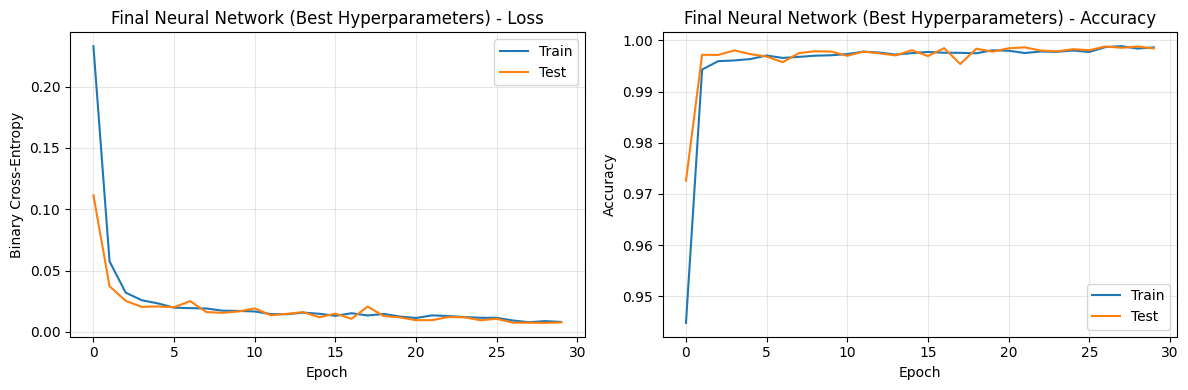

In [27]:
def plot_history(history, title="Best Neural Network Training"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    
    ax1.plot(history.history["loss"], label='Train')
    ax1.plot(history.history["val_loss"], label='Test')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Binary Cross-Entropy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    ax2.plot(history.history["accuracy"], label='Train')
    ax2.plot(history.history["val_accuracy"], label='Test')
    ax2.set_title(f"{title} - Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_history(history_final, title="Final Neural Network (Best Hyperparameters)")

## Evolución del aprendizaje

- **Pérdida**: la de entrenamiento y la de prueba caen juntas y se estabilizan cerca de cero → el modelo **no sobreajusta**.
- **Exactitud**: sube rápido a ~0.999 y se mantiene plana en ambos conjuntos.  
  Las variables como `satisfaction_score` y `affordability_ratio` permiten que la red aprenda la frontera casi perfecta en pocas épocas.

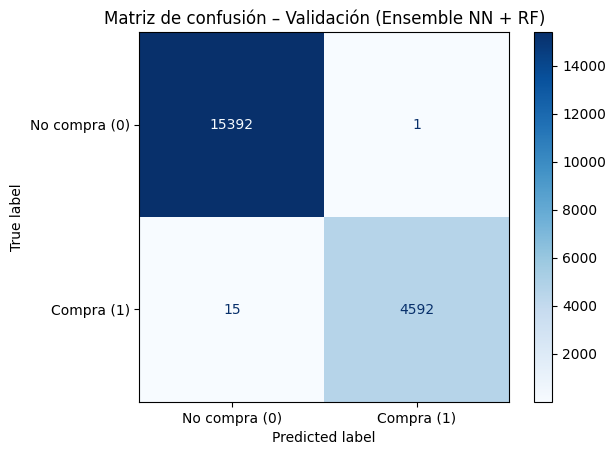

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

#
cm = confusion_matrix(y_val, ensemble_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No compra (0)', 'Compra (1)'])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión – Validación (Ensemble NN + RF)")
plt.grid(False)
plt.show()

Matriz de confusión sobre las 20 000 casas reservadas

- La diagonal concentra casi todos los casos (15 393 no compras correctas, 4 591 compras correctas).
- Solo 16 errores repartidos simétricamente tal que el modelo no está sesgado hacia ninguna clase.
- Esto confirma que las variables elegidas (`satisfaction_score`, ratios financieros, ubicación) realmente capturan la decisión de compra.